In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import *


plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
plt.rc("text", usetex=True)
plt.rc("legend", fontsize=10)


In [2]:
# Load data 
df_muon = pd.read_csv("data/cifar10_muonmax_sweep_data.csv")
df_efmuon = pd.read_csv("data/cifar10_efmuonmax_sweep_data.csv")
df_vanilla_muon = pd.read_csv("data/cifar10_muon_sweep_data.csv")

for df in [df_muon, df_efmuon]:
    df["config"] = df["base_lr"].astype(str) + "_" + df["lr_multiplier"].astype(str) + "_" + df["nesterov"].astype(str)
df_vanilla_muon["config"] = df_vanilla_muon["trial_id"].astype(str) 

best_muon_nadam = get_best_trial(df_muon, "MuonMax")
best_efmuon_nadam = get_best_trial(df_efmuon, "EF-MuonMax")
best_vanilla_muon = get_best_trial(df_vanilla_muon, "Vanilla Muon")

trials = [ 
    ("MuonMax", best_muon_nadam),
    ("EF-MuonMax", best_efmuon_nadam),
    ("Vanilla Muon", best_vanilla_muon),
]
all_dfs = [ 
    ("MuonMax", df_muon),
    ("EF-MuonMax", df_efmuon),
    ("Vanilla Muon", df_vanilla_muon),
]

MuonMax: best config = 0.0005_100.0_False, final valid loss = 0.2651
EF-MuonMax: best config = 0.005_30.0_True, final valid loss = 0.3884
Vanilla Muon: best config = 3, final valid loss = 0.2874


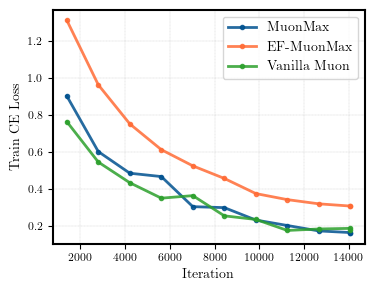

In [3]:
# Train CE loss vs. step (sparse evals)
plot_loss_vs_step(trials, "train/ce_loss", "Train CE Loss",
                  filename="best_train_ce_loss_cifar", sparse=True)

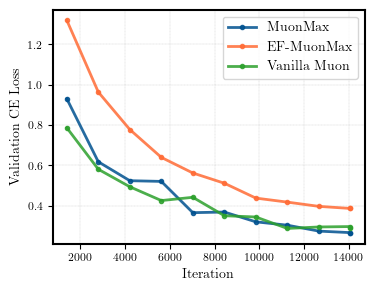

In [4]:
# Validation loss vs. step (sparse evals)
plot_loss_vs_step(trials, "valid/ce_loss", "Validation CE Loss",
                  filename="best_valid_loss_cifar", sparse=True)

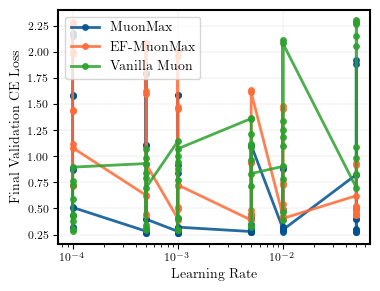

In [5]:
# Validation loss vs. effective LR (sensitivity plot)
plot_final_metric_vs_lr(all_dfs, "valid/ce_loss", "Final Validation CE Loss",
                        filename="valid_loss_vs_lr_cifar")